In [1]:
import scipy.signal as sg
import numpy as np
def fourier_tr_padding_centered(x, y, center_x, n_padding=100):
    N = len(y)
    
    center_idx = np.argmin(np.abs(x - center_x))
    
    half_len = min(center_idx, N - center_idx - 1)
    y_centered = y[center_idx - half_len : center_idx + half_len + 1]
    
    pad_len = len(y_centered) * (n_padding - 1)
    pad_left = pad_len // 2
    pad_right = pad_len - pad_left
    y_pad = np.concatenate([np.zeros(pad_left, dtype=complex),
                            y_centered,
                            np.zeros(pad_right, dtype=complex)])
    y_pad_shifted = np.fft.ifftshift(y_pad)
    data_fft = np.fft.fft(y_pad_shifted)
    freq_fft = np.fft.fftfreq(len(y_pad), x[1] - x[0])
    
    data_fft = np.fft.fftshift(data_fft)
    freq_fft = np.fft.fftshift(freq_fft)
    
    return freq_fft, data_fft

def start_stop(x, y, xstart, xstop):
    x_list = np.array([el for el in x if el>=xstart and el<=xstop])
    x_idx = [i for i, el in enumerate(x) if el>=xstart and el<=xstop]
    y_list = y[x_idx]
    return x_list, y_list

def lowpass(t, x, fp, fs, gpass, gstop):
    samplerate = 1/(t[1]-t[0])
    fn = samplerate / 2                      
    wp = fp / fn                             
    ws = fs / fn                             
    N, Wn = sg.buttord(wp, ws, gpass, gstop) 
    b, a = sg.butter(N, Wn, "low")           
    y = sg.filtfilt(b, a, x)                 
    return y

def demodulate(t, data, demodulation_if = 0.125):
    return (data * np.exp(2j * np.pi * demodulation_if * t)).mean(axis=-1)

# spatiotempioral mode

### secant hyperbolic function

In [2]:
from scipy.special import gamma, zeta
import matplotlib.pyplot as plt

kappa = 2.5e-3*2*np.pi*2

def N_m(m, kappa=kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

# A_list[m] has the coefficients of A_m(t)([a0, a1, ..., am] (t^0, t^1, ..., t^m))
A_list = {}
Z_list = {}

A_list[0] = [1.0]
Z_dict = {
    0: kappa / 4,
    }

def compute_Z_m(m, A_coeffs):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = N_m(Nj_index)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1/Z

def get_A_m(m):
    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = get_A_m(lower_m)

        # sum over j
        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = N_m(m - (i + j))
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = compute_Z_m(m, A_m_coeffs)
    print("Z_m", Z_m, m, A_m_coeffs)
    Z_dict[m] = Z_m

    A_list[m] = A_m_coeffs
    return A_m_coeffs

Z_m 2.3561944901923456e-06 1 [0.0, 1.0]
Z_m 2.2089323345553242e-10 2 [-3333.3333333333326, 0.0, 1.0]
Z_m 9.54476934684399e-15 3 [0.0, -13999.999999999998, 0.0, 1.0]
Z_m 2.348908081449889e-19 4 [77142857.14285716, 0.0, -37142.85714285715, 0.0, 1.0]
Z_m 3.7206704010166296e-24 5 [0.0, 646031746.0317459, 0.0, -77777.77777777778, 0.0, 1.0]
Z_m 4.1053693468007393e-29 6 [-4870129870129.864, 0.0, 2990909090.909087, 0.0, -140909.0909090908, 0.0, 1.0]
Z_m 3.3342233345529004e-34 7 [0.0, -63419580419580.66, 0.0, 10039860139.86017, 0.0, -231538.46153846185, 0.0, 1.0]
Z_m 2.0757493904076642e-39 8 [5.99650349650344e+17, 0.0, -431684848484845.1, 0.0, 27389743589.743458, 0.0, -354666.666666666, 0.0, 1.0]
Z_m 1.0218976575242988e-44 9 [0.0, 1.0786575894693693e+19, 0.0, -2044361990950247.5, 0.0, 64581176470.588585, 0.0, -515294.1176470599, 0.0, 1.0]


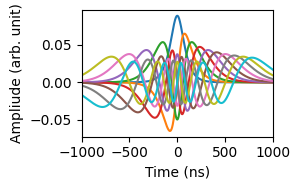

In [3]:
def sech(x):
    return 1 / np.cosh(x)

def xi_m(t, m, kappa):
    A_coeffs = get_A_m(m)
    Zm = Z_dict[m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

plt.figure(figsize=(3, 2))

for m in range(10):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel('Ampliude (arb. unit)')
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(-duration/2, duration/2)
# plt.savefig("Figapp2_a.pdf")
# plt.savefig("Figapp2_a_25.pdf")
plt.show()

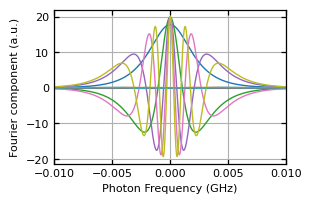

In [4]:

readout_lo_freq = 9.5
target_freq = 9.38
duration = 4000
t_vals = np.linspace(-duration/2, duration/2, duration)
xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(10)]

plt.figure(figsize=(3, 2))
for label, waveform in enumerate(xi_funcs_s):
    waveform = waveform#* np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding_centered(t_vals, waveform, 0)
    photon_freq =  xfft
    plt.plot(photon_freq, fourier.real, label=f'm={label}')

plt.xlabel("Photon Frequency (GHz)")
plt.ylabel("Fourier component (a.u.)")
plt.xlim(-0.01, 0.01)
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()

In [5]:
def transmissivity(omega, omega_0, linewidth):
    gamma = linewidth
    delta = omega - omega_0
    return 1 / (1 + (2 * delta / gamma)**2)

def compute_selectivity(I_normalized):
    M = I_normalized.shape[0]
    return np.mean([np.abs(I_normalized[m, m])**4 / np.sum(np.abs(I_normalized[m, :])**2) for m in range(M)])


NameError: name 'fourier_n' is not defined

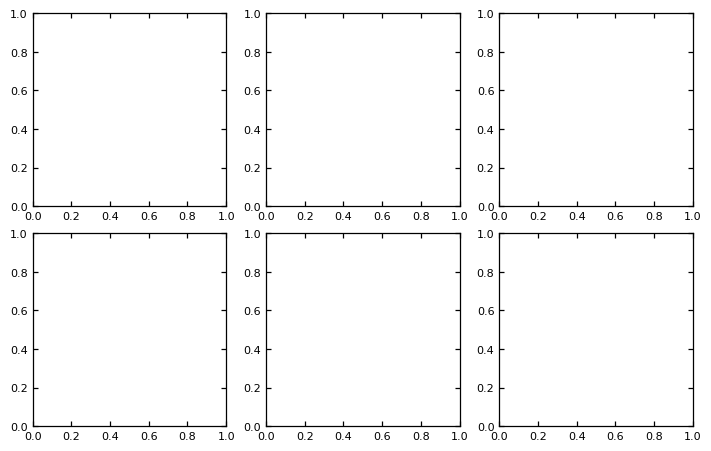

In [6]:
n_max = 7
duration = 2000
linewidths = [0.005, 0.015, 0.03]
freq_target = 9.38
colors = plt.cm.tab10.colors 

gram_matrixs = []
fig, axs = plt.subplots(2, len(linewidths), figsize=(7, 4.4), constrained_layout=True)

t_vals = np.linspace(-duration/2, duration/2, duration)

for idx, linewidth in enumerate(linewidths):
    ax_spec = axs[0, idx]
    ax_heat = axs[1, idx]
    gram_matrix = np.zeros((n_max + 1, n_max + 1))

    ax_scale = None
    for m in range(n_max + 1):
        xi_vals = xi_m(t_vals, m, kappa)
        xfft, fourier_vals = fourier_tr_padding_centered(t_vals, xi_vals, 0)

        # Before filter
        if m % 2 == 0:
            comp_before = fourier_vals.real
        else:
            comp_before = fourier_vals.imag
        if m == 0:
            ax_scale = np.max(np.abs(fourier_n))
        ax_spec.plot(freq_target+xfft, comp_before/ax_scale, color=colors[m],
                     linestyle='-', label=f'm={m}')

        # After filter
        T = transmissivity(xfft, 0, linewidth)
        fourier_filtered = fourier_vals * T
        if m % 2 == 0:
            comp_after = fourier_filtered.real
        else:
            comp_after = fourier_filtered.imag
        ax_spec.plot(freq_target+xfft, comp_after/ax_scale, color=colors[m],
                     linestyle=':')

        # Gram matrix
        
        for n in range(n_max + 1):
            xi_vals_n = xi_m(t_vals, n, kappa)
            _, fourier_n = fourier_tr_padding_centered(t_vals, xi_vals_n, 0)
            fourier_n_filtered = fourier_n * T
            integrand = np.conjugate(fourier_filtered) * fourier_n_filtered
            power_filter_1 = np.trapz(np.abs(fourier_filtered)**2, xfft)
            power_filter_2 = np.trapz(np.abs(fourier_n_filtered)**2, xfft)
            gram_matrix[m, n] = np.abs(np.trapz(integrand, xfft)) / np.sqrt(power_filter_1 * power_filter_2)

    gram_matrixs.append(gram_matrix)

    # --- Spectrum axis ---
    ax_spec.set_xlim(freq_target-0.015, freq_target+0.015)
    ax_spec.set_ylim(-1.1, 1.1)
    ax_spec.set_xlabel("Frequency (GHz)")
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (arb. unit)")
    else:
        ax_spec.tick_params(labelleft=False)

    # --- Heatmap axis ---
    im = ax_heat.imshow(gram_matrix**2, cmap='viridis',
                        interpolation='nearest', origin='lower',
                        vmin=0, vmax=1,
                        extent=(-0.5, n_max+0.5, -0.5, n_max+0.5))
    ax_heat.set_xlabel(r"Photon mode $m^{\prime}$")
    ax_heat.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax_heat.set_ylabel(r"Photon mode $m$", x=-0.2)
        ax_heat.set_yticks(np.arange(n_max + 1))
    else:
        ax_heat.set_yticks([])

    selectivity = compute_selectivity(gram_matrixs[idx])
    print(f"Linewidth = {linewidth}: Selectivity = {selectivity:.4f}")
    for i in range(n_max + 1):
        for j in range(n_max + 1):
            val = gram_matrix[i, j]**2
            if 0.01 < val < 0.99:
                color = 'red' if val > 0.5 else 'white'
                ax_heat.text(j, i, f"{val:.2f}", ha='center', va='center',
                             color=color, fontsize=6)

cbar = fig.colorbar(im, ax=axs[1, :], shrink=0.8, location='right', pad=0.02, fraction=0.046)
cbar.set_label(r'Squared overlap $|I_{m, m^{\prime}}|^2$')

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.48, 1.07), ncol=8, handlelength=1.5, handletextpad=0.5,)

# plt.savefig("Figapp3_a1.pdf", bbox_inches='tight')
plt.show()


# frequency-bin mode

Linewidth = 0.005: Selectivity = 0.1634
Linewidth = 0.015: Selectivity = 0.3961
Linewidth = 0.03: Selectivity = 0.7283


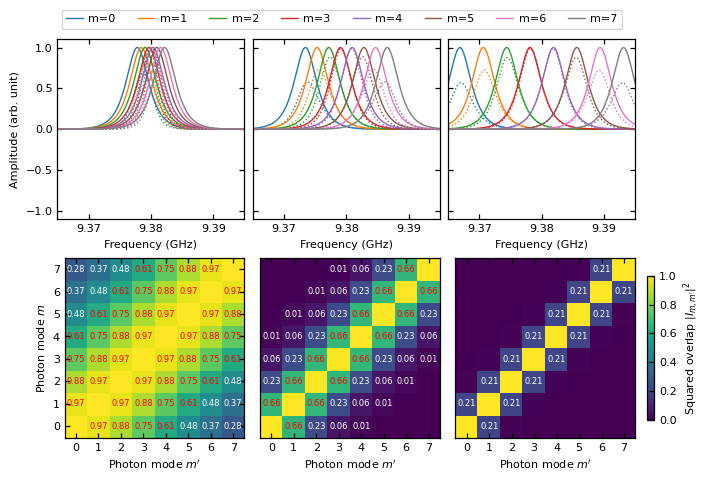

In [7]:

n_max = 7
duration = 2000
linewidths = [0.005, 0.015, 0.03]
freq_target = 9.38

gram_matrixs = []
fig, axs = plt.subplots(2, len(linewidths), figsize=(7, 4.4),
                        constrained_layout=True)

t_vals = np.linspace(-duration/2, duration/2, duration)
base_waveform = xi_m(t_vals, 0, kappa) 
colors = plt.cm.tab10(np.arange(n_max + 1) % 10)
ax_scale = None
for idx, linewidth in enumerate(linewidths):
    ax_spec = axs[0, idx]
    ax_heat = axs[1, idx]
    gram_matrix = np.zeros((n_max + 1, n_max + 1))

    # frequency bin spacing
    bin_spacing = linewidth / (n_max + 1)

    for m in range(n_max + 1):
        freq_shift = (m - n_max/2) * bin_spacing
        xi_bin = base_waveform * np.exp(1j * 2 * np.pi * freq_shift * t_vals)
        
        # Fourier transform
        xfft, fourier_vals = fourier_tr_padding_centered(t_vals, xi_bin, 0)
        if m == 0:
            ax_scale = np.max(np.abs(fourier_vals))
        ax_spec.plot(freq_target+xfft, fourier_vals.real/ax_scale, color=colors[m],
                     linestyle='-', label=f'm={m}')

        T = transmissivity(xfft, 0, linewidth)
        fourier_filtered = fourier_vals * T
        ax_spec.plot(freq_target+xfft, fourier_filtered.real/ax_scale, color=colors[m],
                     linestyle=':')

        for n in range(n_max + 1):
            freq_shift_n = (n - n_max/2) * bin_spacing
            xi_bin_n = base_waveform * np.exp(1j * 2 * np.pi * freq_shift_n * t_vals)
            _, fourier_n = fourier_tr_padding_centered(t_vals, xi_bin_n, 0)
            fourier_n_filtered = fourier_n * T

            integrand = np.conjugate(fourier_filtered) * fourier_n_filtered
            power_filter_1 = np.trapz(np.abs(fourier_filtered)**2, xfft)
            power_filter_2 = np.trapz(np.abs(fourier_n_filtered)**2, xfft)
            gram_matrix[m, n] = np.abs(np.trapz(integrand, xfft)) / np.sqrt(power_filter_1 * power_filter_2)

    gram_matrixs.append(gram_matrix)

    ax_spec.set_xlim(freq_target-0.015, freq_target+0.015)
    ax_spec.set_ylim(-1.1, 1.1)
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (arb. unit)")
    else:
        ax_spec.tick_params(labelleft=False)
    ax_spec.set_xlabel("Frequency (GHz)")

    # --- Heatmap plot ---
    im = ax_heat.imshow(gram_matrix**2, cmap='viridis',
                        origin='lower', vmin=0, vmax=1,
                        extent=(-0.5, n_max+0.5, -0.5, n_max+0.5))
    ax_heat.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax_heat.set_yticks(np.arange(n_max + 1))
        ax_heat.set_ylabel(r"Photon mode $m$")
    else:
        ax_heat.set_yticks([])
    ax_heat.set_xlabel(r"Photon mode $m^{\prime}$")
    selectivity = compute_selectivity(gram_matrixs[idx])
    print(f"Linewidth = {linewidth}: Selectivity = {selectivity:.4f}")
    for i in range(n_max + 1):
        for j in range(n_max + 1):
            val = gram_matrix[i, j]**2
            if 0.01 < val < 0.99:
                color = "red" if val > 0.5 else "white"
                ax_heat.text(j, i, f"{val:.2f}", ha="center", va="center",
                             color=color, fontsize=6)

cbar = fig.colorbar(im, ax=axs[1, :], shrink=0.8, location="right", pad=0.02, fraction=0.046)
cbar.set_label(r'Squared overlap $|I_{m, m^{\prime}}|^2$')

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.48, 1.07), ncol=8, handlelength=1.5, handletextpad=0.5,)

# plt.savefig("Figapp3_c1.pdf", bbox_inches="tight")
plt.show()

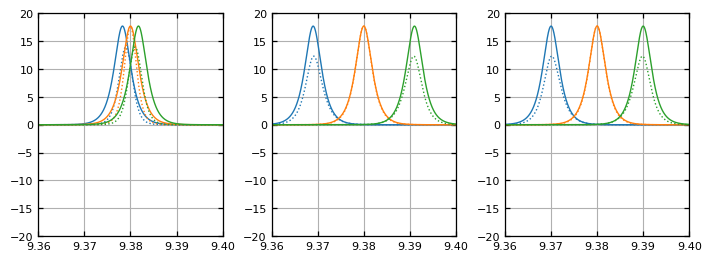

In [155]:

n_max = 2
duration = 2000
linewidths = [0.0052, 0.033, 0.03]
freq_target = 9.38

gram_matrixs = []
fig, axs = plt.subplots(1, len(linewidths), figsize=(7, 2.5),
                        constrained_layout=True)

t_vals = np.linspace(-duration/2, duration/2, duration)
base_waveform = xi_m(t_vals, 0, kappa) 
colors = plt.cm.tab10(np.arange(n_max + 1) % 10)

for idx, linewidth in enumerate(linewidths):
    ax_spec = axs[idx]
    gram_matrix = np.zeros((n_max + 1, n_max + 1))

    # frequency bin spacing
    bin_spacing = linewidth / (n_max + 1)

    for m in range(n_max + 1):
        freq_shift = (m - n_max/2) * bin_spacing
        xi_bin = base_waveform * np.exp(1j * 2 * np.pi * freq_shift * t_vals)

        # Fourier transform
        xfft, fourier_vals = fourier_tr_padding_centered(t_vals, xi_bin, 0)

        ax_spec.plot(freq_target+xfft, fourier_vals.real, color=colors[m],
                     linestyle='-', label=f'm={m}')

        T = transmissivity(xfft, 0, linewidth)
        fourier_filtered = fourier_vals * T
        ax_spec.plot(freq_target+xfft, fourier_filtered.real, color=colors[m],
                     linestyle=':')
    ax_spec.set_xlim(freq_target-0.02, freq_target+0.02)
    ax_spec.set_ylim(-20, 20)
    ax_spec.grid(True)

## compute selectivity

In [8]:
bandwidth_list = np.linspace(0, 40, 17)
m_range = np.arange(1, 21)
duration = 4000
epsilon_s_map = np.zeros((len(m_range), len(bandwidth_list)))
epsilon_f_map = np.zeros((len(m_range), len(bandwidth_list)))
t_vals = np.linspace(-duration/2, duration/2, int(duration))
base_waveform = xi_m(t_vals, 0, kappa)

show_plot = False

for i, m_tot in enumerate(m_range):
    fourier_vals_all = np.array([
        fourier_tr_padding_centered(t_vals, xi_m(t_vals, m, kappa), 0)[1] 
        for m in range(m_tot)
    ])
    xfft, _ = fourier_tr_padding_centered(t_vals, xi_m(t_vals, 0, kappa), 0)
    dx = np.diff(xfft).mean() 

    for j, linewidth in enumerate(bandwidth_list):
        if np.isclose(linewidth, 0):
            epsilon_s_map[i, j] = 0
            epsilon_f_map[i, j] = 0
            continue

        n_max = m_tot - 1
        bin_spacing = linewidth * 0.001 / (n_max + 1)
        T = transmissivity(xfft, 0, linewidth*0.001)

        # --- Spatiotemporal modes Gram matrix ---
        fourier_filtered_s = fourier_vals_all * T
        overlap_s = fourier_filtered_s @ (fourier_filtered_s.conj().T) * dx
        gram_matrix_s = np.abs(overlap_s)
        power_s = np.sqrt(np.diag(gram_matrix_s))
        gram_matrix_s /= np.outer(power_s, power_s)
        epsilon_s_map[i, j] = compute_selectivity(gram_matrix_s)

        # --- Frequency-bin modes Gram matrix ---
        fourier_vals_all_f = np.array([
            fourier_tr_padding_centered(
                t_vals,
                base_waveform * np.exp(1j * 2 * np.pi * (m - n_max/2) * bin_spacing * t_vals),
                0
            )[1] 
            for m in range(m_tot)
        ])
        fourier_filtered_f = fourier_vals_all_f * T
        overlap_f = fourier_filtered_f @ (fourier_filtered_f.conj().T) * dx
        gram_matrix_f = np.abs(overlap_f)
        power_f = np.sqrt(np.diag(gram_matrix_f))
        gram_matrix_f /= np.outer(power_f, power_f)
        epsilon_f_map[i, j] = compute_selectivity(gram_matrix_f)

        if show_plot:
            fig, axs = plt.subplots(2, 2, figsize=(10, 5))
            
            # Spatiotemporal waveforms
            for m in range(m_tot):
                axs[0, 0].plot(xfft, fourier_vals_all[m].real, label=f'm={m} before', linestyle='-')
                axs[0, 0].plot(xfft, (fourier_vals_all[m]*T).real, label=f'm={m} after', linestyle=':')
            axs[0, 0].set_title(f"Spatiotemporal modes\nBandwidth={linewidth:.3f}")
            axs[0, 0].set_xlim(-0.02, 0.02)

            # Frequency-bin waveforms
            for m in range(m_tot):
                axs[0, 1].plot(xfft, fourier_vals_all_f[m].real, label=f'm={m} before', linestyle='-')
                axs[0, 1].plot(xfft, (fourier_vals_all_f[m]*T).real, label=f'm={m} after', linestyle=':')
            axs[0, 1].set_title("Frequency-bin modes")
            axs[0, 1].set_xlim(-0.02, 0.02)

            # Gram matrix^2 plots
            im_s = axs[1, 0].imshow(gram_matrix_s**2, cmap='viridis', origin='lower', vmin=0, vmax=1)
            axs[1, 0].set_title("Gram matrix^2 (Spatiotemporal)")
            plt.colorbar(im_s, ax=axs[1, 0])

            im_f = axs[1, 1].imshow(gram_matrix_f**2, cmap='viridis', origin='lower', vmin=0, vmax=1)
            axs[1, 1].set_title("Gram matrix^2 (Frequency-bin)")
            plt.colorbar(im_f, ax=axs[1, 1])

            plt.tight_layout()
            plt.show()

    print(f"the number of mode: {m_tot} finished")


the number of mode: 1 finished
the number of mode: 2 finished
the number of mode: 3 finished
the number of mode: 4 finished
the number of mode: 5 finished
the number of mode: 6 finished
the number of mode: 7 finished
the number of mode: 8 finished
the number of mode: 9 finished
the number of mode: 10 finished
Z_m 4.077371653521792e-50 10 [-1.2180513758686839e+23, 0.0, 9.847339604667594e+19, 0.0, -7607956656346659.0, 0.0, 136623529411.76384, 0.0, -718421.0526315769, 0.0, 1.0]
the number of mode: 11 finished
Z_m 1.345106556007919e-55 11 [0.0, -2.825207617460148e+24, 0.0, 6.108448223500302e+20, 0.0, -2.379371517027971e+16, 0.0, 265769924812.03833, 0.0, -969047.6190476349, 0.0, 1.0]
the number of mode: 12 finished
Z_m 3.729920282138782e-61 12 [3.6922339946360564e+28, 0.0, -3.2675083218273307e+25, 0.0, 2.9170165284693323e+21, 0.0, -6.520789931349824e+16, 0.0, 483542236024.8305, 0.0, -1272173.91304346, 0.0, 1.0]
the number of mode: 13 finished
Z_m 8.81515419784242e-67 13 [0.0, 1.055765907870

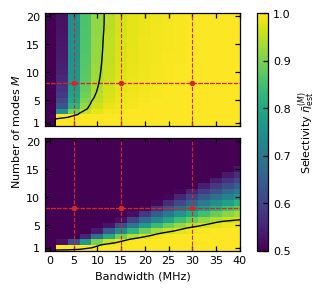

M = 8, Frequency bandwidth = 5 MHz
  Spatiotemporal separability : 0.7723
  Frequency-bin separability      : 0.1634
--------------------------------------------------
M = 8, Frequency bandwidth = 15 MHz
  Spatiotemporal separability : 0.9777
  Frequency-bin separability      : 0.3961
--------------------------------------------------
M = 8, Frequency bandwidth = 30 MHz
  Spatiotemporal separability : 0.9979
  Frequency-bin separability      : 0.7283
--------------------------------------------------


In [9]:
# --- Meshgrid for plotting ---
X, Y = np.meshgrid(bandwidth_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_f_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)

axs[1].set_xlabel("Bandwidth (MHz)")
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# Colorbar
fig.colorbar(c2, ax=axs, label=r"Selectivity $\bar{\eta}_\text{est}^{(M)}$")

# x-limits
axs[0].set_xlim(-1, 40)
axs[1].set_xlim(-1, 40)

target_M = 8
target_bandwidths = [5, 15, 30]

i_M = np.where(m_range == target_M)[0][0]

for bandwidth in target_bandwidths:
    j_dur = np.argmin(np.abs(bandwidth_list - bandwidth))
    dur_val = bandwidth_list[j_dur]
    for ax in axs:
        ax.axvline(x=dur_val, color='tab:red', linestyle='--', linewidth=0.8)
    for ax in axs:
        ax.axhline(y=target_M, color='tab:red', linestyle='--', linewidth=0.8)
    for ax, data_map in zip(axs, [epsilon_s_map, epsilon_f_map]):
            value = data_map[i_M, j_dur]
            ax.plot(dur_val, target_M, marker='o', color='tab:red', markersize=3)
for ax in axs:
    ax.set_xticks([0, 5, 10, 15, 20, 25, 30, 35, 40])
    ax.set_yticks([1, 5, 10, 15, 20])


# Z shape: (ny, nx)
ny, nx = epsilon_s_map.shape

# X, Y は (ny, nx)
Xc = np.zeros_like(epsilon_s_map)
Yc = np.zeros_like(epsilon_s_map)

# X の中央座標
for i in range(nx):
    if i == 0:
        Xc[:, i] = X[:, i] - (X[:, 1]-X[:, 0])/2
    elif i == nx-1:
        Xc[:, i] = X[:, i] + (X[:, i]-X[:, i-1])/2
    else:
        Xc[:, i] = (X[:, i-1]+X[:, i])/2

# Y の中央座標
for j in range(ny):
    if j == 0:
        Yc[j, :] = Y[j, :] - (Y[j+1, :]-Y[j, :])/2
    elif j == ny-1:
        Yc[j, :] = Y[j, :] + (Y[j, :]-Y[j-1, :])/2
    else:
        Yc[j, :] = (Y[j-1, :]+Y[j, :])/2

# contour で描画
axs[0].contour(Xc, Yc, epsilon_s_map, levels=[0.95], colors='black', linewidths=1.0)
axs[1].contour(Xc, Yc, epsilon_f_map, levels=[0.95], colors='black', linewidths=1.0)
plt.savefig("Fig4_b1.pdf", bbox_inches='tight')
plt.show()
# --- Print specific values ---

i_M = np.where(m_range == target_M)[0][0]

for bandwidth in target_bandwidths:
    j_band = np.argmin(np.abs(bandwidth_list - bandwidth))
    separability_s = epsilon_s_map[i_M, j_band]
    separability_f = epsilon_f_map[i_M, j_band]
    print(f"M = {target_M}, Frequency bandwidth = {bandwidth} MHz")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)


In [198]:
bandwidth_list = np.linspace(0, 40, 17)
m_range = np.arange(1, 21)
duration = 4000
epsilon_s_map = np.zeros((len(m_range), len(bandwidth_list)))
epsilon_f_map = np.zeros((len(m_range), len(bandwidth_list)))
t_vals = np.linspace(-duration/2, duration/2, int(duration))
base_waveform = xi_m(t_vals, 0, kappa)

show_plot = False

for i, m_tot in enumerate(m_range):
    fourier_vals_all = np.array([fourier_tr_padding_centered(t_vals, xi_m(t_vals, m, kappa), 0)[1] 
                                 for m in range(m_tot)])
    xfft, _ = fourier_tr_padding_centered(t_vals, xi_m(t_vals, 0, kappa), 0)

    for j, linewidth in enumerate(bandwidth_list):
        bin_spacing = linewidth*0.001 / (n_max + 1)
        if np.isclose(linewidth, 0):
            epsilon_s_map[i, j] = 0
            epsilon_f_map[i, j] = 0
            continue

        T = transmissivity(xfft, 0, linewidth*0.001)

        # --- Spatiotemporal modes Gram matrix ---
        fourier_filtered_s = fourier_vals_all * T
        power_s = np.trapz(np.abs(fourier_filtered_s)**2, xfft, axis=1)
        gram_matrix_s = np.abs(np.trapz(np.conj(fourier_filtered_s[:, None, :]) * fourier_filtered_s[None, :, :], xfft, axis=2))
        gram_matrix_s /= np.sqrt(power_s[:, None] * power_s[None, :])
        epsilon_s_map[i, j] = compute_selectivity(gram_matrix_s)

        # --- Frequency-bin modes Gram matrix ---
        n_max = m_tot - 1
        fourier_vals_all_f = np.array([fourier_tr_padding_centered(t_vals, base_waveform * np.exp(1j * 2 * np.pi * (m - n_max/2) * bin_spacing * t_vals), 0)[1] 
                                       for m in range(m_tot)])
        fourier_filtered_f = np.abs(fourier_vals_all_f * T)
        power_f = np.trapz(np.abs(fourier_filtered_f)**2, xfft, axis=1)
        gram_matrix_f = np.abs(np.trapz(np.conj(fourier_filtered_f[:, None, :]) * fourier_filtered_f[None, :, :], xfft, axis=2))
        gram_matrix_f /= np.sqrt(power_f[:, None] * power_f[None, :])
        epsilon_f_map[i, j] = compute_selectivity(gram_matrix_f)

        if show_plot:
            fig, axs = plt.subplots(2, 2, figsize=(10, 5))
            
            # Spatiotemporal waveforms
            for m in range(m_tot):
                axs[0, 0].plot(xfft, fourier_vals_all[m].real, label=f'm={m} before', linestyle='-')
                axs[0, 0].plot(xfft, (fourier_vals_all[m]*T).real, label=f'm={m} after', linestyle=':')
            axs[0, 0].set_title(f"Spatiotemporal modes\nBandwidth={linewidth:.3f}")
            axs[0, 0].set_xlim(-0.02, 0.02)
            # axs[0, 0].legend(fontsize=6)

            # Frequency-bin waveforms
            for m in range(m_tot):
                axs[0, 1].plot(xfft, fourier_vals_all_f[m].real, label=f'm={m} before', linestyle='-')
                axs[0, 1].plot(xfft, (fourier_vals_all_f[m]*T).real, label=f'm={m} after', linestyle=':')
            axs[0, 1].set_title("Frequency-bin modes")
            axs[0, 1].set_xlim(-0.02, 0.02)
            # axs[0, 1].legend(fontsize=6)

            # Gram matrix^2 plots
            im_s = axs[1, 0].imshow(gram_matrix_s**2, cmap='viridis', origin='lower', vmin=0, vmax=1)
            axs[1, 0].set_title("Gram matrix^2 (Spatiotemporal)")
            plt.colorbar(im_s, ax=axs[1, 0])

            im_f = axs[1, 1].imshow(gram_matrix_f**2, cmap='viridis', origin='lower', vmin=0, vmax=1)
            axs[1, 1].set_title("Gram matrix^2 (Frequency-bin)")
            plt.colorbar(im_f, ax=axs[1, 1])

            plt.tight_layout()
            plt.show()

    print(f"the number of mode: {m_tot} finished")


the number of mode: 1 finished
the number of mode: 2 finished
the number of mode: 3 finished
the number of mode: 4 finished
the number of mode: 5 finished
the number of mode: 6 finished
the number of mode: 7 finished
the number of mode: 8 finished
the number of mode: 9 finished
the number of mode: 10 finished
the number of mode: 11 finished
the number of mode: 12 finished
the number of mode: 13 finished
the number of mode: 14 finished


MemoryError: Unable to allocate 1.34 GiB for an array with shape (15, 15, 399899) and data type complex128

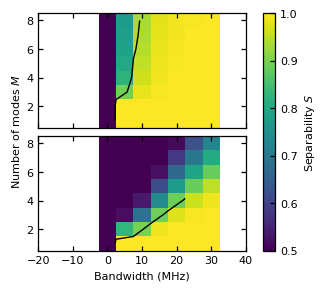

M = 8, Frequency bandwidth = 5 MHz
  Spatiotemporal separability : 0.7723
  Frequency-bin separability      : 0.1733
--------------------------------------------------
M = 8, Frequency bandwidth = 15 MHz
  Spatiotemporal separability : 0.9777
  Frequency-bin separability      : 0.3961
--------------------------------------------------
M = 8, Frequency bandwidth = 30 MHz
  Spatiotemporal separability : 0.9979
  Frequency-bin separability      : 0.7283
--------------------------------------------------


In [192]:
# --- Meshgrid for plotting ---
X, Y = np.meshgrid(bandwidth_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_f_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)

axs[1].set_xlabel("Bandwidth (MHz)")
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# Colorbar
fig.colorbar(c2, ax=axs, label=r"Separability $S$")

# x-limits
axs[0].set_xlim(-20, 40)
axs[1].set_xlim(-20, 40)

# --- Contour for separability = 0.95 ---
Xc = X[:, :-1] - np.diff(X, axis=1)/2
Yc = Y[:, :-1]

contour_s = axs[0].contour(Xc, Yc, epsilon_s_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
contour_t = axs[1].contour(Xc, Yc, epsilon_f_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)

plt.show()

# --- Print specific values ---
target_M = 8
target_bandwidths = [5, 15, 30]
i_M = np.where(m_range == target_M)[0][0]

for bandwidth in target_bandwidths:
    j_band = np.argmin(np.abs(bandwidth_list - bandwidth))
    separability_s = epsilon_s_map[i_M, j_band]
    separability_f = epsilon_f_map[i_M, j_band]
    print(f"M = {target_M}, Frequency bandwidth = {bandwidth} MHz")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)


the number of mode: 1 finished
the number of mode: 2 finished
the number of mode: 3 finished
the number of mode: 4 finished
the number of mode: 5 finished
the number of mode: 6 finished
the number of mode: 7 finished
the number of mode: 8 finished
the number of mode: 9 finished


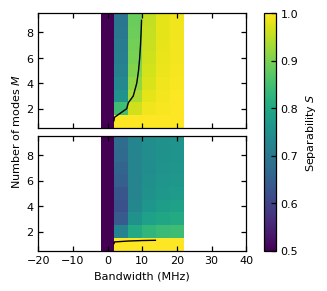

M = 8, Frequency bandwidth = 5 MHz
  Spatiotemporal separability : 0.6999
  Frequency-bin separability      : 0.6706
--------------------------------------------------
M = 8, Frequency bandwidth = 15 MHz
  Spatiotemporal separability : 0.9802
  Frequency-bin separability      : 0.7533
--------------------------------------------------
M = 8, Frequency bandwidth = 30 MHz
  Spatiotemporal separability : 0.9902
  Frequency-bin separability      : 0.7583
--------------------------------------------------


In [178]:
bandwidth_list = np.linspace(0, 20, 6)
m_range = np.arange(1, 10)
duration = 4000
epsilon_s_map = np.zeros((len(m_range), len(bandwidth_list)))
epsilon_f_map = np.zeros((len(m_range), len(bandwidth_list)))
t_vals = np.linspace(-duration/2, duration/2, int(duration))
base_waveform = xi_m(t_vals, 0, kappa)

# --- Main loop over number of modes and bandwidth ---
for i, m_tot in enumerate(m_range):
    # Precompute temporal-mode Fourier transforms
    fourier_vals_all = np.array([fourier_tr_padding_centered(t_vals, xi_m(t_vals, m, kappa), 0)[1] 
                                 for m in range(m_tot + 1)])
    xfft, _ = fourier_tr_padding_centered(t_vals, xi_m(t_vals, 0, kappa), 0)  # frequency axis

    for j, linewidth in enumerate(bandwidth_list):
        if np.isclose(linewidth, 0):
            epsilon_s_map[i, j] = 0
            epsilon_f_map[i, j] = 0
            continue

        T = transmissivity(xfft, 0, linewidth*0.001)

        # --- Spatiotemporal modes Gram matrix ---
        fourier_filtered_s = fourier_vals_all * T
        power_s = np.trapz(np.abs(fourier_filtered_s)**2, xfft, axis=1)
        gram_matrix_s = np.abs(np.trapz(np.conj(fourier_filtered_s[:, None, :]) * fourier_filtered_s[None, :, :], xfft, axis=2))
        gram_matrix_s /= np.sqrt(power_s[:, None] * power_s[None, :])
        epsilon_s_map[i, j] = compute_selectivity(gram_matrix_s)

        # --- Frequency-bin modes Gram matrix ---
        n_max = m_tot - 1
        fourier_vals_all_f = np.array([fourier_tr_padding_centered(t_vals, base_waveform * np.exp(1j * 2 * np.pi * (m - n_max/2) * bin_spacing * t_vals), 0)[1] 
                                 for m in range(m_tot)])
        xfft, _ = fourier_tr_padding_centered(t_vals, xi_m(t_vals, 0, kappa), 0) 
        gram_matrix_f = np.zeros((n_max + 1, n_max + 1))
        fourier_filtered_f = np.abs(fourier_vals_all_f * T)
        power_f = np.trapz(np.abs(fourier_filtered_f)**2, xfft, axis=1)
        gram_matrix_f = np.abs(np.trapz(np.conj(fourier_filtered_f[:, None, :]) * fourier_filtered_f[None, :, :], xfft, axis=2))
        gram_matrix_f /= np.sqrt(power_f[:, None] * power_f[None, :])
        epsilon_f_map[i, j] = compute_selectivity(gram_matrix_f)

    print(f"the number of mode: {m_tot} finished")

# --- Meshgrid for plotting ---
X, Y = np.meshgrid(bandwidth_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_f_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)

axs[1].set_xlabel("Bandwidth (MHz)")
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# Colorbar
fig.colorbar(c2, ax=axs, label=r"Separability $S$")

# x-limits
axs[0].set_xlim(-20, 40)
axs[1].set_xlim(-20, 40)

# --- Contour for separability = 0.95 ---
Xc = X[:, :-1] - np.diff(X, axis=1)/2
Yc = Y[:, :-1]

contour_s = axs[0].contour(Xc, Yc, epsilon_s_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
contour_t = axs[1].contour(Xc, Yc, epsilon_f_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)

plt.show()

# --- Print specific values ---
target_M = 8
target_bandwidths = [5, 15, 30]
i_M = np.where(m_range == target_M)[0][0]

for bandwidth in target_bandwidths:
    j_band = np.argmin(np.abs(bandwidth_list - bandwidth))
    separability_s = epsilon_s_map[i_M, j_band]
    separability_f = epsilon_f_map[i_M, j_band]
    print(f"M = {target_M}, Frequency bandwidth = {bandwidth} MHz")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)


In [177]:
target_M = 9
target_bandwidths = [5, 15, 30]
i_M = np.where(m_range == target_M)[0][0]

for bandwidth in target_bandwidths:
    j_band = np.argmin(np.abs(bandwidth_list - bandwidth))
    separability_s = epsilon_s_map[i_M, j_band]
    separability_f = epsilon_f_map[i_M, j_band]
    print(f"M = {target_M}, Frequency bandwidth = {bandwidth} MHz")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)

M = 9, Frequency bandwidth = 5 MHz
  Spatiotemporal separability : 0.6954
  Frequency-bin separability      : 0.6777
--------------------------------------------------
M = 9, Frequency bandwidth = 15 MHz
  Spatiotemporal separability : 0.9793
  Frequency-bin separability      : 0.7514
--------------------------------------------------
M = 9, Frequency bandwidth = 30 MHz
  Spatiotemporal separability : 0.9898
  Frequency-bin separability      : 0.7560
--------------------------------------------------


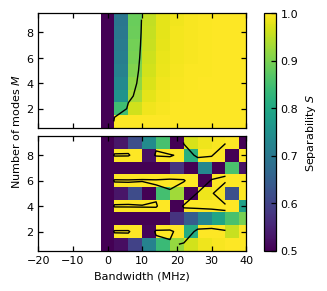

M = 8, Frequency bandwidth = 5 MHz
  Spatiotemporal separability : 0.6994
  Frequency-bin separability      : 1.0000
--------------------------------------------------
M = 8, Frequency bandwidth = 15 MHz
  Spatiotemporal separability : 0.9802
  Frequency-bin separability      : 1.0000
--------------------------------------------------
M = 8, Frequency bandwidth = 30 MHz
  Spatiotemporal separability : 0.9970
  Frequency-bin separability      : 1.0000
--------------------------------------------------


In [134]:
X, Y = np.meshgrid(bandwidth_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_f_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)

axs[1].set_xlabel("Bandwidth (MHz)")
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# Colorbar
fig.colorbar(c2, ax=axs, label=r"Separability $S$")

# x-limits
axs[0].set_xlim(-20, 40)
axs[1].set_xlim(-20, 40)

# --- Contour for separability = 0.95 ---
Xc = X[:, :-1] - np.diff(X, axis=1)/2
Yc = Y[:, :-1]

contour_s = axs[0].contour(Xc, Yc, epsilon_s_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
contour_t = axs[1].contour(Xc, Yc, epsilon_f_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)

plt.show()

# --- Print specific values ---
target_M = 8
target_bandwidths = [5, 15, 30]
i_M = np.where(m_range == target_M)[0][0]

for bandwidth in target_bandwidths:
    j_band = np.argmin(np.abs(bandwidth_list - bandwidth))
    separability_s = epsilon_s_map[i_M, j_band]
    separability_f = epsilon_f_map[i_M, j_band]
    print(f"M = {target_M}, Frequency bandwidth = {bandwidth} MHz")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)


In [116]:
bandwidth_list = np.linspace(0, 200, 21)
m_range = np.arange(1, 20)

epsilon_s_map = np.zeros((len(m_range), len(bandwidth_list)))
epsilon_f_map = np.zeros((len(m_range), len(bandwidth_list)))

for i, m_tot in enumerate(m_range):
    for j, bandwidth in enumerate(bandwidth_list):
        if np.isclose(bandwidth, 0):
            epsilon_s = 0
            epsilon_f = 0
        else:
            t_vals = np.linspace(-duration/2, duration/2, int(duration))
            T = transmissivity(xfft, 0, linewidth)

            gram_matrix_s = np.zeros((m_tot + 1, m_tot + 1))
            for m in range(m_tot + 1):
                xi_vals = xi_m(t_vals, m, kappa)
                xfft, fourier_vals = fourier_tr_padding_centered(t_vals, xi_vals, 0)
                fourier_filtered = fourier_vals * T
                for n in range(m_tot + 1):
                    xi_vals_n = xi_m(t_vals, n, kappa)
                    _, fourier_n = fourier_tr_padding_centered(t_vals, xi_vals_n, 0)
                    fourier_n_filtered = fourier_n * T
                    integrand = np.conjugate(fourier_filtered) * fourier_n_filtered
                    power_filter_1 = np.trapz(np.abs(fourier_filtered)**2, xfft)
                    power_filter_2 = np.trapz(np.abs(fourier_n_filtered)**2, xfft)
                    gram_matrix_s[m, n] = np.abs(np.trapz(integrand, xfft)) / np.sqrt(power_filter_1 * power_filter_2)

            gram_matrix_f = np.zeros((m_tot + 1, m_tot + 1))
            bin_spacing = linewidth / (m_tot + 1)
            for m in range(m_tot + 1):
                freq_shift = (m - m_tot/2) * bin_spacing
                xi_bin = base_waveform * np.exp(1j * 2 * np.pi * freq_shift * t_vals)
                xfft, fourier_vals = fourier_tr_padding_centered(t_vals, xi_bin, 0)
                fourier_filtered = fourier_vals * T
                for n in range(m_tot + 1):
                    freq_shift_n = (n - m_tot/2) * bin_spacing
                    xi_bin_n = base_waveform * np.exp(1j * 2 * np.pi * freq_shift_n * t_vals)
                    _, fourier_n = fourier_tr_padding_centered(t_vals, xi_bin_n, 0)
                    fourier_n_filtered = fourier_n * T
                    integrand = np.conjugate(fourier_filtered) * fourier_n_filtered
                    power_filter_1 = np.trapz(np.abs(fourier_filtered)**2, xfft)
                    power_filter_2 = np.trapz(np.abs(fourier_n_filtered)**2, xfft)
                    gram_matrix_f[m, n] = np.abs(np.trapz(integrand, xfft)) / np.sqrt(power_filter_1 * power_filter_2)
                    
            epsilon_s = compute_selectivity(gram_matrix_s) 
            epsilon_f = compute_selectivity(gram_matrix_f) 

        epsilon_s_map[i, j] = epsilon_s
        epsilon_f_map[i, j] = epsilon_f


X, Y = np.meshgrid(bandwidth_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# axs[0].set_title("Spatiotemporal")
# axs[0].set_xlabel("Communication time (ns)")
# axs[0].set_ylabel("Number of modes $M$")
# fig.colorbar(c1, ax=axs[0], label=r"Basis fidelity $F(M)$")
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_f_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# axs[1].set_title("Time-bin")
axs[1].set_xlabel("Bandwidth (MHz)")
# axs[1].set_ylabel("Number of modes $M$")
fig.colorbar(c2, ax=axs, label=r"Separability $S$")
axs[0].set_xlim(-20, 200)
axs[1].set_xlim(-20, 200)
# === black line ===
target_M = 10
target_bandwisths = [5, 15, 30]

# i_M = np.where(m_range == target_M)[0][0]

# for duration in target_durations:
#     j_dur = np.argmin(np.abs(bandwidth_list - duration))
#     dur_val = bandwidth_list[j_dur]
#     for ax in axs:
#         ax.axvline(x=dur_val, color='tab:red', linestyle='--', linewidth=0.8)
#     for ax in axs:
#         ax.axhline(y=target_M, color='tab:red', linestyle='--', linewidth=0.8)
#     for ax, data_map in zip(axs, [epsilon_s_map, epsilon_f_map]):
#             value = data_map[i_M, j_dur]
#             ax.plot(dur_val, target_M, marker='o', color='tab:red', markersize=3)
# for ax in axs:
    # ax.set_yticks([0, 5, 10, 15, 20])

# === Separability = 0.95 ===

# contour_s = axs[0].contour(X-0.2, Y, epsilon_s_map, levels=[0.95], colors='black', linewidths=1.0)
# contour_t = axs[1].contour(X-0.2, Y, epsilon_t_map, levels=[0.95], colors='black', linewidths=1.0)
Xc = X[:, :-1] - np.diff(X, axis=1)/2  # center of each pcolormesh cell (x-direction)
Yc = Y[:, :-1]  # same shape as Xc (y-direction constant per row)

contour_s = axs[0].contour(Xc, Yc, epsilon_s_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
contour_t = axs[1].contour(Xc, Yc, epsilon_f_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# plt.savefig('Fig4_a_25.pdf', bbox_inches='tight')

plt.show()
target_M = 8
target_bandwidths = [5, 15, 30]

i_M = np.where(m_range == target_M)[0][0]


for bandwidth in target_bandwidths:
    j_dur = np.argmin(np.abs(bandwidth_list - bandwidth))
    
    separability_s = epsilon_s_map[i_M, j_dur]
    separability_f = epsilon_f_map[i_M, j_dur]
    
    print(f"M = {target_M}, Frequency bandwidth = {bandwidth} ns")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)

C:\Users\qipe\AppData\Local\Temp\ipykernel_18840\1277702167.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix_s[m, n] = np.trapz(integrand, xfft) / np.sqrt(power_filter_1 * power_filter_2)
C:\Users\qipe\AppData\Local\Temp\ipykernel_18840\1277702167.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix_f[m, n] = np.trapz(integrand, xfft) / np.sqrt(power_filter_1 * power_filter_2)


Z_m 4.077371653521792e-50 10 [-1.2180513758686839e+23, 0.0, 9.847339604667594e+19, 0.0, -7607956656346659.0, 0.0, 136623529411.76384, 0.0, -718421.0526315769, 0.0, 1.0]
Z_m 1.345106556007919e-55 11 [0.0, -2.825207617460148e+24, 0.0, 6.108448223500302e+20, 0.0, -2.379371517027971e+16, 0.0, 265769924812.03833, 0.0, -969047.6190476349, 0.0, 1.0]
Z_m 3.729920282138782e-61 12 [3.6922339946360564e+28, 0.0, -3.2675083218273307e+25, 0.0, 2.9170165284693323e+21, 0.0, -6.520789931349824e+16, 0.0, 483542236024.8305, 0.0, -1272173.91304346, 0.0, 1.0]
Z_m 8.81515419784242e-67 13 [0.0, 1.0557659078707675e+30, 0.0, -2.5296166124001544e+26, 0.0, 1.1497650924485222e+22, 0.0, -1.6105146732919053e+17, 0.0, 833006086956.5013, 0.0, -1632799.999999963, 0.0, 1.0]
Z_m 1.7967164038146261e-72 14 [-1.5622799277138163e+34, 0.0, 1.488144074929407e+31, 0.0, -1.4872269807884837e+27, 0.0, 3.908880369916438e+22, 0.0, -3.6565072367128e+17, 0.0, 1371295851851.3027, 0.0, -2055925.9259255116, 0.0, 1.0]
Z_m 3.1906134262460

KeyboardInterrupt: 

## DPSS

In [ ]:
from scipy.integrate import simpson
from scipy.fft import fft, fftfreq, fftshift

def spectral_concentration(signal, t_vals, W=0.1):
    dt = t_vals[1] - t_vals[0]
    freq = fftshift(fftfreq(len(signal), d=dt))
    spectrum = fftshift(np.abs(fft(signal)))**2
    total_power = simpson(spectrum, x=freq)
    
    # Concentrated power in [-W, W]
    mask = (freq >= -W) & (freq <= W)
    concentrated_power = simpson(spectrum[mask], x=freq[mask])
    # plt.plot(freq, spectrum, label='|signal|')
    # plt.plot(freq[mask], spectrum[mask], label='masked')
    # plt.axvspan(-W, W, color='orange', alpha=0.2)
    # plt.legend()
    # plt.xlabel("Time")
    # plt.ylabel("Amplitude")
    # plt.xlim(-0.05, 0.05)
    # plt.title(f"Temporal Concentration in [-{W}, {W}]")
    # plt.grid(True)
    # plt.show()
    return concentrated_power / total_power

def temporal_concentration(signal, t_vals, T=1.0):
    total_power = simpson(np.abs(signal)**2, x=t_vals)

    mask = (t_vals >= -T) & (t_vals <= T)
    concentrated_power = simpson(np.abs(signal[mask])**2, x=t_vals[mask])

    # plt.plot(t_vals, np.abs(signal), label='|signal|')
    # plt.plot(t_vals[mask], np.abs(signal)[mask], label='masked')
    # plt.axvspan(-T, T, color='orange', alpha=0.2)
    # plt.legend()
    # plt.xlabel("Time")
    # plt.ylabel("Amplitude")
    # plt.title(f"Temporal Concentration in [-{T}, {T}]")
    # plt.grid(True)
    # plt.show()

    return concentrated_power / total_power

In [ ]:
from scipy.interpolate import interp1d
duration = 6000
duration_t = 8000
t_vals = np.linspace(-duration/2, duration/2, duration)
t_vals_t = np.linspace(-duration_t/2, duration_t/2, duration_t)
num_modes=10
NW = duration*kappa/8 # time-bandwidth product 

readout_lo_freq = 9.5
target_freq = 9.35
xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(num_modes)]
xi_funcs_s_t = [xi_m((t_vals_t), m, kappa) for m in range(num_modes)]
fouriers_s = []
for label, waveform in enumerate(xi_funcs_s):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    fouriers_s.append(fourier)

dpss_modes = windows.dpss(duration, NW, Kmax=num_modes)

fouriers_d = []
for label, waveform in enumerate(dpss_modes):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    fouriers_d.append(fourier)

sc_results = {
    'xi_m': [],
    'dpss': []
}
tc_results = {
    'xi_m': [],
    'dpss': []
}
W_band = kappa/2/4
T_band = duration/6
fig, axs = plt.subplots(num_modes, 2, figsize=(10, 16))
for m in range(num_modes):

    interp_fn = interp1d(t_vals, dpss_modes[m], kind='cubic', fill_value=0.0, bounds_error=False)
    signal_scaled = interp_fn(t_vals_t)


    axs[m, 0].plot(t_vals_t, xi_funcs_s_t[m], label="sech", lw=2)
    axs[m, 0].plot(t_vals_t, signal_scaled, label="DPSS", lw=2, ls='--')
    axs[m, 0].set_title(f"Time Domain m={m}")
    axs[m, 0].set_xlim(-2000, 2000)
    axs[m, 0].axvspan(-T_band, T_band, color='orange', alpha=0.2)

    axs[m, 1].plot(photon_freq, fouriers_s[m], label="sech", lw=2)
    axs[m, 1].plot(photon_freq, fouriers_d[m], label="DPSS", lw=2, ls='--')
    axs[m, 1].set_xlim(9.33, 9.37)
    axs[m, 1].set_title(f"Frequency Domain m={m}")
    center_freq = target_freq 
    axs[m, 1].axvspan(center_freq - W_band, center_freq + W_band, color='purple', alpha=0.2)

    if m == num_modes - 1:
        axs[m, 0].set_xlabel("Time (ns)")
    axs[m, 0].set_ylabel("Amplitude")
    if m == 0:
        axs[m, 0].legend(loc='upper right')
    if m == num_modes - 1:
        axs[m, 1].set_xlabel("Frequency (GHz)")
    if m == 0:
        axs[m, 1].legend(loc='upper right')

    sc_xi = spectral_concentration(xi_funcs_s[m], t_vals, W=W_band)
    sc_dpss = spectral_concentration(dpss_modes[m], t_vals, W=W_band)
    sc_results['xi_m'].append(sc_xi)
    sc_results['dpss'].append(sc_dpss)

    tc_xi = temporal_concentration(xi_funcs_s_t[m], t_vals_t, T=T_band)
    tc_dpss = temporal_concentration(signal_scaled, t_vals_t, T=T_band)
    tc_results['xi_m'].append(tc_xi)
    tc_results['dpss'].append(tc_dpss)

plt.tight_layout()
plt.show()

print("time", tc_results)
print("freq", sc_results)

tf_score_geom = {
    "xi_m": [np.sqrt(tc * fc) for tc, fc in zip(tc_results["xi_m"], sc_results["xi_m"])],
    "dpss": [np.sqrt(tc * fc) for tc, fc in zip(tc_results["dpss"], sc_results["dpss"])]
}

x = np.arange(num_modes)

fig, ax = plt.subplots()

ax.plot(x, tf_score_geom['xi_m'],  label='sech', marker='o')
ax.plot(x, tf_score_geom['dpss'],label='dpss',marker= 'o')

ax.set_ylabel('Time-Frequency Concentration')
ax.set_xlabel('Mode')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}' for i in x])
ax.legend()
ax.set_ylim(0.0, 1.2)

plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'windows' is not defined

In [ ]:
for m in range(num_modes):
    norm_xi = np.sqrt(simpson(np.abs(xi_funcs_s[m])**2, x=t_vals))
    norm_dpss = np.sqrt(simpson(np.abs(dpss_modes[m])**2, x=t_vals))
    print(f"m={m}: ||xi||={norm_xi:.4f}, ||dpss||={norm_dpss:.4f}")

m=0: ||xi||=1.0000, ||dpss||=1.0001
m=1: ||xi||=1.0000, ||dpss||=1.0001
m=2: ||xi||=1.0000, ||dpss||=1.0001
m=3: ||xi||=1.0000, ||dpss||=1.0001
m=4: ||xi||=1.0000, ||dpss||=1.0001
m=5: ||xi||=1.0000, ||dpss||=1.0001
m=6: ||xi||=1.0000, ||dpss||=1.0001
m=7: ||xi||=1.0000, ||dpss||=1.0001
m=8: ||xi||=1.0000, ||dpss||=1.0001
m=9: ||xi||=1.0000, ||dpss||=1.0001
